# Part 3: Clustering Analysis

In this section, I use K-Means clustering to segment employees into meaningful groups based on their demographic, compensation, satisfaction, workload, and tenure-related characteristics.

The aim is to identify hidden employee groups that may not be obvious from basic exploratory analysis.

Because clustering is an unsupervised learning method, the target variable `Attrition` will not be used to create the clusters. Instead, attrition will only be analysed after the clusters have been created to understand whether some groups have higher leaving risk.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Feature-Engineered Dataset

I will now load the feature-engineered and scaled dataset created in Part 2.

This dataset has already been cleaned, encoded, and scaled, making it suitable for K-Means clustering.

In [4]:
df = pd.read_csv("../data/processed/hr_attrition_feature_engineered.csv")

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


In [5]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1470, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 58 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   float64
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   float64
 3   DistanceFromHome                   1470 non-null   float64
 4   Education                          1470 non-null   float64
 5   EmployeeNumber                     1470 non-null   float64
 6   EnvironmentSatisfaction            1470 non-null   float64
 7   Gender                             1470 non-null   float64
 8   HourlyRate                         1470 non-null   float64
 9   JobInvolvement                     1470 non-null   float64
 10  JobLevel                           1470 non-null   float64
 11  JobSatisfaction               

## 2. Prepare Data for Clustering

The target variable `Attrition` must be excluded from clustering because K-Means is unsupervised. Including the target would leak information into the clustering process and make the segmentation less realistic.

If present, employee identifier columns such as `EmployeeNumber` should also be removed because they do not describe employee behaviour or HR characteristics.

In [6]:
# Create a copy of the dataset
df_cluster = df.copy()

# Keep Attrition separately for later interpretation
attrition = df_cluster["Attrition"]

# Columns to exclude from clustering
exclude_cols = ["Attrition"]

# Remove EmployeeNumber if it exists because it is only an identifier
if "EmployeeNumber" in df_cluster.columns:
    exclude_cols.append("EmployeeNumber")

# Create clustering feature matrix
X_cluster = df_cluster.drop(columns=exclude_cols)

print("Clustering feature shape:", X_cluster.shape)
X_cluster.head()

Clustering feature shape: (1470, 56)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


## 3. Choosing the Number of Clusters

To decide the best number of clusters, I will test K values from 2 to 10 using:

- Elbow method: shows how compact the clusters are.
- Silhouette score: shows how well-separated the clusters are.

The final K should not be selected based only on the chart. It should also make business sense and produce interpretable employee groups.

In [7]:
# Store results
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

# Run K-Means for each K
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_cluster)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, cluster_labels))

# Create results table
k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_scores,
    "SilhouetteScore": silhouette_scores
})

k_results

,K,Inertia,SilhouetteScore
0,2,75057.505115,0.124096
1,3,70667.807758,0.083900
2,4,68434.026388,0.064730
3,5,66337.068106,0.076999
4,6,64605.944524,0.079537
5,7,63281.001488,0.076942
6,8,62292.006092,0.069793
7,9,60709.745666,0.078411
8,10,59314.518893,0.081095


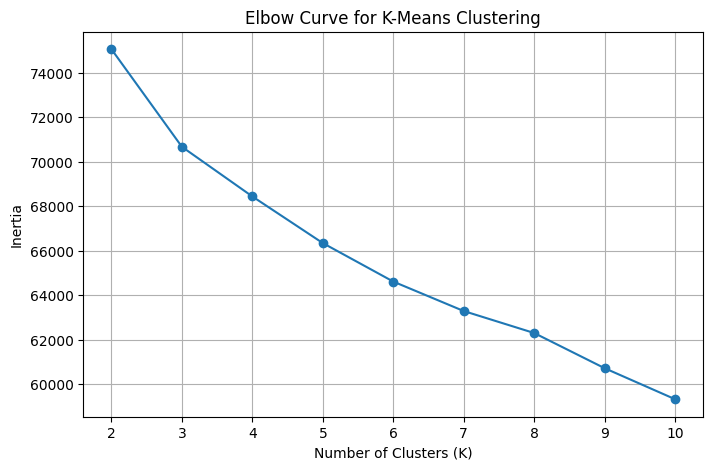

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(k_results["K"], k_results["Inertia"], marker="o")

plt.title("Elbow Curve for K-Means Clustering")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

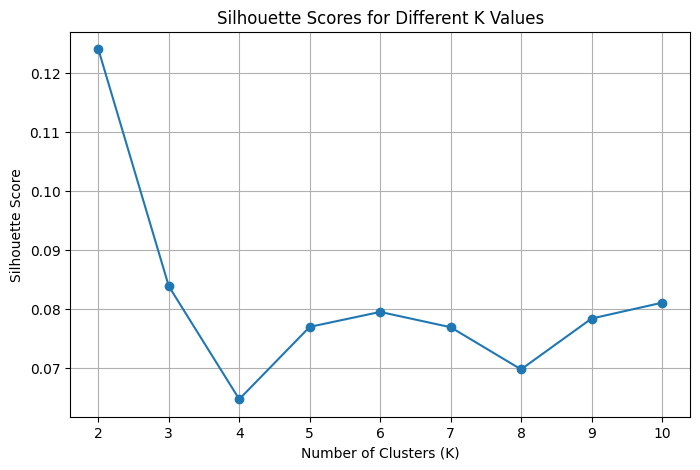

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(k_results["K"], k_results["SilhouetteScore"], marker="o")

plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

### Choosing the Best K

The elbow curve shows a strong reduction in inertia between K = 2 and K = 5, after which the rate of improvement begins to slow down. This suggests that adding more clusters beyond this point produces diminishing returns in terms of cluster compactness.

The silhouette score is highest at K = 2 with a score of approximately 0.124. However, while K = 2 provides the strongest mathematical separation, it produces only two very broad employee groups, which may oversimplify the workforce and limit the usefulness of the segmentation for HR decision-making.

After K = 2, the silhouette scores become lower but relatively stable between K = 5 and K = 10. Among these values, K = 5 provides a good balance between cluster separation, business interpretability, and practical usefulness.

From a business perspective, K = 5 allows the company to identify multiple employee personas such as:
- high-risk early-career employees,
- overworked employees,
- stable long-tenure employees,
- compensation-sensitive employees,
- and highly satisfied core employees.

This level of segmentation is detailed enough to support targeted HR interventions while still remaining understandable for non-technical stakeholders.

Although higher K values such as K = 7 or K = 10 provide more granular segmentation, they may create clusters that are too small or too complex for practical business action.

Based on both the clustering metrics and business interpretability, I selected K = 5 as the final number of clusters for the employee segmentation analysis.

In [10]:
# Choose final K after reviewing elbow and silhouette results
final_k = 5

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df_cluster["Cluster"] = final_kmeans.fit_predict(X_cluster)

df_cluster["Cluster"].value_counts().sort_index()

Cluster
0     83
1    262
2    305
3    497
4    323
Name: count, dtype: int64

## 4. Cluster Profiling

After creating the clusters, I will profile each group by calculating average values for key variables.

This helps translate numerical clusters into business-friendly employee segments.

I will also calculate attrition rate per cluster to understand whether some groups appear more at risk of leaving.

In [11]:
cluster_size = df_cluster["Cluster"].value_counts().sort_index()

cluster_size_df = pd.DataFrame({
    "Cluster": cluster_size.index,
    "Number of Employees": cluster_size.values,
    "Percentage of Workforce": (cluster_size.values / len(df_cluster) * 100).round(2)
})

cluster_size_df

,Cluster,Number of Employees,Percentage of Workforce
0,0,83,5.65
1,1,262,17.82
2,2,305,20.75
3,3,497,33.81
4,4,323,21.97


In [12]:
cluster_attrition = df_cluster.groupby("Cluster")["Attrition"].agg(
    total_employees="count",
    attrition_count="sum",
    attrition_rate="mean"
).reset_index()

cluster_attrition["attrition_rate"] = (cluster_attrition["attrition_rate"] * 100).round(2)

cluster_attrition

,Cluster,total_employees,attrition_count,attrition_rate
0,0,83,33,39.76
1,1,262,18,6.87
2,2,305,53,17.38
3,3,497,100,20.12
4,4,323,33,10.22


In [13]:
# Select key features for cluster profiling
profile_columns = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "JobSatisfaction",
    "WorkLifeBalance",
    "YearsAtCompany",
    "TotalWorkingYears",
    "OvertimeRisk",
    "WorkLifeSatisfactionScore",
    "IncomeGrowthPotential"
]

# Keep only columns that exist in the dataframe
profile_columns = [col for col in profile_columns if col in df_cluster.columns]

cluster_profile = df_cluster.groupby("Cluster")[profile_columns].mean().round(2)

cluster_profile

,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential
Cluster,,,,,,,,,,
0,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42
1,1.02,1.81,-0.03,-0.04,0.01,1.09,1.56,0.02,-0.03,0.25
2,-0.08,0.02,0.05,0.06,0.07,-0.06,-0.14,0.01,0.09,0.22
3,-0.28,-0.62,-0.07,-0.01,-0.04,-0.68,-0.58,0.01,-0.03,0.00
4,-0.14,-0.32,0.11,-0.01,-0.06,0.38,-0.02,-0.05,-0.04,-0.52


### Cluster Profile Findings

#### Cluster 0 — High-Risk Early-Career Employees

- This cluster contains approximately 5.65% of the workforce.
- Employees in this group show lower-than-average income, lower tenure, and lower total working years.
- The cluster also shows slightly higher work-life balance and satisfaction scores compared with some other groups, but still records the highest attrition rate overall.
- Attrition rate: 39.76%.

Business interpretation:
This cluster appears to represent younger or less experienced employees who may still be exploring career opportunities or seeking faster growth elsewhere. Despite not showing extremely poor satisfaction scores, their low tenure and lower compensation may make them more likely to leave.

Potential HR action:
- Improve onboarding and mentorship programmes.
- Increase career development visibility.
- Review early-career compensation and progression pathways.
- Introduce retention-focused engagement during the first few years of employment.

**"Early-Career Flight Risk Employees"**

---

#### Cluster 1 — Stable High-Value Experienced Employees

- This cluster represents approximately 17.82% of the workforce.
- Employees in this group have the highest income levels, longest tenure, and highest total working years among all clusters.
- Attrition rate is the lowest among all clusters at 6.87%.
- Overtime risk and satisfaction levels appear relatively stable.

Business interpretation:
This cluster likely represents experienced, well-established employees with strong organisational attachment and higher compensation. These employees may occupy senior, specialist, or leadership-oriented roles.

Potential HR action:
- Focus on retention through leadership development and recognition.
- Preserve engagement through career advancement opportunities.
- Use this group as mentors for newer employees.

**"Stable Experienced Core Employees"**

---

#### Cluster 2 — Balanced Mid-Level Employees

- This cluster contains approximately 20.75% of the workforce.
- Employees in this group appear close to average across most variables including income, tenure, satisfaction, and overtime exposure.
- Attrition rate is moderate at 17.38%.

Business interpretation:
This cluster may represent mid-level employees who are relatively stable but not strongly attached to the organisation. Because they are close to organisational averages, they may become vulnerable to attrition if external opportunities become more attractive.

Potential HR action:
- Maintain engagement initiatives.
- Monitor career progression and internal mobility opportunities.
- Improve long-term development planning.

**"Moderately Stable Mid-Career Employees"**

---

#### Cluster 3 — Compensation-Sensitive Employees

- This is the largest cluster, representing approximately 33.81% of the workforce.
- Employees in this cluster have lower-than-average income, lower tenure, and lower total working years.
- Work-life balance and job satisfaction also appear slightly below average.
- Attrition rate is relatively high at 20.12%.

Business interpretation:
This group may include employees who feel financially undervalued or insufficiently rewarded relative to their workload or expectations. Their lower satisfaction and compensation levels may contribute to increased turnover risk.

Potential HR action:
- Review compensation fairness and promotion pathways.
- Improve employee recognition programmes.
- Provide clearer career growth opportunities.

**"Compensation-Sensitive Retention Risk Employees"**

---

#### Cluster 4 — Long-Tenure Moderately Stable Employees

- This cluster represents approximately 21.97% of the workforce.
- Employees in this group have above-average tenure but only moderately below-average income.
- Overtime exposure appears slightly lower than average.
- Attrition rate is relatively low at 10.22%.

Business interpretation:
This cluster appears to represent employees who have developed moderate organisational loyalty over time. Although they are not among the highest earners, their longer tenure suggests stronger stability and attachment to the organisation.

Potential HR action:
- Maintain retention through engagement and recognition.
- Continue supporting work-life balance initiatives.
- Offer skill development and internal mobility opportunities to prevent stagnation.

**"Stable Long-Tenure Employees"**

In [14]:
cluster_summary = cluster_profile.merge(
    cluster_attrition,
    on="Cluster",
    how="left"
)

cluster_summary

,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,total_employees,attrition_count,attrition_rate
0,0,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42,83,33,39.76
1,1,1.02,1.81,-0.03,-0.04,0.01,1.09,1.56,0.02,-0.03,0.25,262,18,6.87
2,2,-0.08,0.02,0.05,0.06,0.07,-0.06,-0.14,0.01,0.09,0.22,305,53,17.38
3,3,-0.28,-0.62,-0.07,-0.01,-0.04,-0.68,-0.58,0.01,-0.03,0.00,497,100,20.12
4,4,-0.14,-0.32,0.11,-0.01,-0.06,0.38,-0.02,-0.05,-0.04,-0.52,323,33,10.22


## 5. Business-Friendly Cluster Names

The purpose of clustering is not just to produce numbers. The clusters should be translated into employee personas that HR and business stakeholders can understand.

Each cluster is given a business-friendly name based on its profile.

In [16]:
cluster_name_map = {
    0: "Early-Career Flight Risk Employees",
    1: "Stable Experienced Core Employees",
    2: "Moderately Stable Mid-Career Employees",
    3: "Compensation-Sensitive Retention Risk Employees",
    4: "Stable Long-Tenure Employees"
}

# Map cluster names
df_cluster["ClusterName"] = df_cluster["Cluster"].map(cluster_name_map)

# Preview results
df_cluster[["Cluster", "ClusterName"]].head(10)

,Cluster,ClusterName
0,2,Moderately Stable Mid-Career Employees
1,4,Stable Long-Tenure Employees
2,3,Compensation-Sensitive Retention Risk Employees
3,4,Stable Long-Tenure Employees
4,3,Compensation-Sensitive Retention Risk Employees
5,4,Stable Long-Tenure Employees
6,3,Compensation-Sensitive Retention Risk Employees
7,3,Compensation-Sensitive Retention Risk Employees
8,4,Stable Long-Tenure Employees
9,4,Stable Long-Tenure Employees


### Cluster Naming Justification

The clusters were renamed using business-friendly labels to make the segmentation easier for HR stakeholders and non-technical audiences to understand.

The names were based on:
- attrition risk,
- employee tenure,
- income levels,
- experience,
- and satisfaction-related characteristics.

Cluster naming allows the clustering analysis to move beyond technical segmentation and become more actionable from a workforce management perspective.

Summary of cluster names:

- Cluster 0 → Early-Career Flight Risk Employees
- Cluster 1 → Stable Experienced Core Employees
- Cluster 2 → Moderately Stable Mid-Career Employees
- Cluster 3 → Compensation-Sensitive Retention Risk Employees
- Cluster 4 → Stable Long-Tenure Employees

## 6. PCA Visualisation

Since the dataset has many features, PCA is used to reduce the data to two dimensions for visualisation.

This does not replace the full clustering analysis. It simply helps visualise how the clusters separate in a two-dimensional space.

In [17]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({
    "PCA1": pca_components[:, 0],
    "PCA2": pca_components[:, 1],
    "Cluster": df_cluster["Cluster"],
    "Attrition": df_cluster["Attrition"]
})

pca_df.head()

,PCA1,PCA2,Cluster,Attrition
0,-0.053900,2.506083,2,1
1,0.555332,-1.320352,4,0
2,-2.420448,-1.525058,3,1
3,-1.431671,-1.014485,4,0
4,-2.501139,-1.494964,3,0


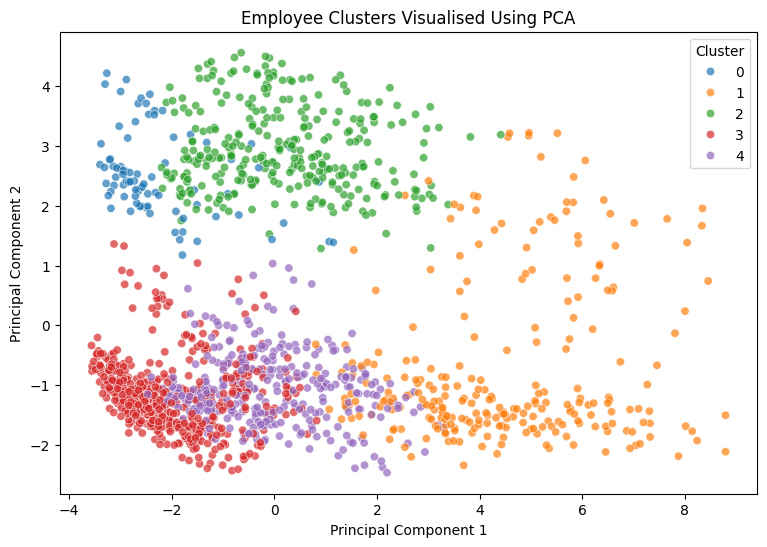

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("Employee Clusters Visualised Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### PCA Visualisation Findings

The PCA visualisation shows that the K-Means clustering model successfully identified several distinct employee groupings within the workforce, although some overlap exists between clusters. This overlap is expected because employee behaviour, satisfaction, compensation, and tenure patterns are naturally interconnected and cannot always be perfectly separated.

Cluster 1 appears to be one of the most clearly separated groups, suggesting that these employees have noticeably different characteristics compared with the rest of the workforce. Based on earlier profiling, this likely represents the highly experienced and well-compensated employee group with lower attrition risk.

Clusters 0 and 3 show partial overlap in the lower-left region of the plot, which may indicate that both groups share similarities such as lower income, shorter tenure, or increased attrition vulnerability. However, the clustering model still distinguishes them based on more detailed combinations of workforce characteristics.

Cluster 2 appears concentrated in the upper region of the PCA space, suggesting a more balanced employee profile that differs moderately from the higher-risk or highly experienced groups.

Cluster 4 occupies a middle region between several groups, which may indicate employees with moderate stability and tenure characteristics.

Overall, the PCA plot supports the idea that the workforce is not homogeneous. Instead, the employees naturally separate into several meaningful segments with different levels of stability, experience, compensation, and attrition risk.

From a business perspective, this visualisation demonstrates that employee attrition risk is likely driven by multiple interacting factors rather than a single variable alone. The clustering analysis therefore provides HR teams with a more strategic way to understand workforce diversity and design targeted retention interventions for different employee groups.

# Clustering Depth Track

For the depth track, I will compare K-Means clustering at three different values of K:

- K = 3
- K = 5
- K = 7

This allows me to understand how employee personas change as the number of clusters increases.

The aim is to compare:
- interpretability,
- business usefulness,
- cluster granularity,
- strengths and weaknesses of each segmentation structure.

In [20]:
def run_kmeans_profile(X, original_df, k, profile_columns):
    """
    Runs K-Means for a selected K and returns cluster labels,
    cluster sizes, attrition rates, and profile summary.
    """
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    temp_df = original_df.copy()
    temp_df[f"Cluster_K{k}"] = model.fit_predict(X)
    
    # Cluster size
    size = temp_df[f"Cluster_K{k}"].value_counts().sort_index()
    
    size_df = pd.DataFrame({
        "Cluster": size.index,
        "Number of Employees": size.values,
        "Percentage of Workforce": (size.values / len(temp_df) * 100).round(2)
    })
    
    # Attrition rate
    attrition_df = temp_df.groupby(f"Cluster_K{k}")["Attrition"].agg(
        total_employees="count",
        attrition_count="sum",
        attrition_rate="mean"
    ).reset_index()
    
    attrition_df["attrition_rate"] = (attrition_df["attrition_rate"] * 100).round(2)
    attrition_df = attrition_df.rename(columns={f"Cluster_K{k}": "Cluster"})
    
    # Profile
    available_profile_cols = [col for col in profile_columns if col in temp_df.columns]
    profile_df = temp_df.groupby(f"Cluster_K{k}")[available_profile_cols].mean().round(2).reset_index()
    profile_df = profile_df.rename(columns={f"Cluster_K{k}": "Cluster"})
    
    # Merge summary
    summary = profile_df.merge(size_df, on="Cluster").merge(attrition_df, on="Cluster")
    
    return temp_df, summary

In [21]:
depth_k_values = [3, 5, 7]

depth_results = {}

for k in depth_k_values:
    temp_df, summary = run_kmeans_profile(
        X=X_cluster,
        original_df=df_cluster,
        k=k,
        profile_columns=profile_columns
    )
    
    depth_results[k] = {
        "data": temp_df,
        "summary": summary
    }
    
    print(f"\nK = {k} Cluster Summary")
    display(summary)


K = 3 Cluster Summary


,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,Number of Employees,Percentage of Workforce,total_employees,attrition_count,attrition_rate
0,0,-0.24,-0.52,-0.01,0.00,-0.05,-0.29,-0.39,-0.01,-0.02,-0.20,797,54.22,797,132,16.56
1,1,-0.22,-0.16,0.03,0.04,0.09,-0.19,-0.29,0.01,0.09,0.26,387,26.33,387,86,22.22
2,2,0.96,1.68,-0.02,-0.07,0.02,1.08,1.48,0.00,-0.05,0.21,286,19.46,286,19,6.64



K = 5 Cluster Summary


,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,Number of Employees,Percentage of Workforce,total_employees,attrition_count,attrition_rate
0,0,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42,83,5.65,83,33,39.76
1,1,1.02,1.81,-0.03,-0.04,0.01,1.09,1.56,0.02,-0.03,0.25,262,17.82,262,18,6.87
2,2,-0.08,0.02,0.05,0.06,0.07,-0.06,-0.14,0.01,0.09,0.22,305,20.75,305,53,17.38
3,3,-0.28,-0.62,-0.07,-0.01,-0.04,-0.68,-0.58,0.01,-0.03,0.00,497,33.81,497,100,20.12
4,4,-0.14,-0.32,0.11,-0.01,-0.06,0.38,-0.02,-0.05,-0.04,-0.52,323,21.97,323,33,10.22



K = 7 Cluster Summary


,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,Number of Employees,Percentage of Workforce,total_employees,attrition_count,attrition_rate
0,0,-0.35,-0.73,0.00,-0.02,-0.11,-0.42,-0.52,-0.12,-0.08,-0.23,243,16.53,243,62,25.51
1,1,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42,83,5.65,83,33,39.76
2,2,-0.34,-0.73,-0.05,0.03,-0.12,-0.42,-0.55,0.11,-0.04,-0.29,311,21.16,311,57,18.33
3,3,1.15,1.77,-0.06,0.01,-0.03,-0.27,1.43,0.03,-0.00,0.41,132,8.98,132,6,4.55
4,4,0.01,-0.04,0.06,-0.03,0.08,0.05,-0.02,-0.04,0.02,-0.07,255,17.35,255,13,5.10
5,5,-0.11,-0.00,0.07,0.03,0.07,-0.07,-0.18,0.02,0.07,0.23,296,20.14,296,51,17.23
6,6,0.84,1.65,-0.03,-0.07,0.06,2.23,1.60,-0.04,-0.02,0.03,150,10.20,150,15,10.00


## K = 3 Cluster Interpretation

K = 3 creates a broad segmentation structure that divides the workforce into three major employee groups.

Cluster observations:
- One cluster represents highly experienced and highly compensated employees with the lowest attrition risk at approximately 6.64%.
- Another cluster contains a large portion of the workforce with moderate income and experience levels but a relatively higher attrition rate of approximately 22.22%.
- The remaining cluster contains employees with lower income and lower experience levels with an attrition rate of approximately 16.56%.

Strengths:
- The segmentation is simple and easy for HR stakeholders to understand.
- It provides a strong high-level overview of the workforce structure.
- The clusters are large enough to support broad organisational strategy.
- Clear separation exists between experienced high-income employees and lower-experience employees.

Weaknesses:
- The clusters are very broad and may hide important employee differences.
- Some high-risk employees may be grouped together with more stable employees.
- Important subgroups such as burnout-risk employees or compensation-sensitive employees are not clearly isolated.
- The segmentation may be too general for targeted HR intervention planning.

Business interpretation:
K = 3 is useful for broad workforce segmentation and executive-level workforce understanding. However, the segmentation is relatively coarse and may oversimplify employee behaviour patterns. While it identifies experienced stable employees successfully, it does not provide enough granularity to design highly targeted retention strategies.

## K = 5 Cluster Interpretation

K = 5 provides a more balanced and actionable employee segmentation structure. The additional clusters allow the model to separate employees into more meaningful workforce personas while still remaining understandable for business stakeholders.

Cluster observations:
- Cluster 0 represents a small but very high-risk employee group with the highest attrition rate at approximately 39.76%.
- Cluster 1 represents highly experienced and highly compensated employees with the lowest attrition rate at approximately 6.87%.
- Cluster 2 contains more balanced mid-level employees with moderate attrition risk.
- Cluster 3 represents a large compensation-sensitive workforce segment with relatively high attrition risk at approximately 20.12%.
- Cluster 4 represents more stable long-tenure employees with relatively low attrition risk.

Strengths:
- Provides a strong balance between detail and interpretability.
- Allows HR teams to identify specific workforce personas.
- Clearly separates high-risk employee groups from stable employee groups.
- Supports targeted retention strategies and workforce planning.
- Produces clusters that remain large enough to be business actionable.

Weaknesses:
- Some overlap between clusters still exists.
- Certain workforce behaviours may still remain blended within broader groups.
- Slightly more complex to explain compared with K = 3.

Business interpretation:
K = 5 appears to provide the best balance between statistical segmentation quality and practical HR usefulness. The segmentation is detailed enough to identify meaningful employee personas while remaining simple enough for business stakeholders to understand and act upon. This structure supports targeted interventions related to onboarding, compensation, wellbeing, and retention.

## K = 7 Cluster Interpretation

K = 7 creates a more granular segmentation structure that divides the workforce into smaller and more specialised employee groups.

Cluster observations:
- Several smaller high-risk and low-risk employee groups become more visible.
- One cluster continues to show extremely high attrition risk near 40%.
- Additional clusters separate different types of experienced employees and compensation-related workforce segments.
- Smaller specialised employee groups begin to emerge with distinct combinations of tenure, income, and satisfaction patterns.

Strengths:
- Provides deeper workforce segmentation and greater analytical detail.
- Captures smaller employee subgroups that may be hidden in broader clustering structures.
- Helps identify more nuanced retention-risk patterns.
- Useful for advanced workforce strategy and detailed HR analytics.

Weaknesses:
- The segmentation becomes more complex and harder for non-technical stakeholders to interpret.
- Some clusters become relatively small, which may reduce practical business usefulness.
- HR intervention planning may become more difficult due to the increased number of employee personas.
- The additional complexity may not provide enough extra business value compared with K = 5.

Business interpretation:
K = 7 provides the most detailed segmentation and reveals deeper workforce complexity. However, the increased granularity also reduces interpretability and may make implementation more difficult for HR teams. While useful for advanced workforce analysis, the segmentation may be too detailed for practical organisation-wide retention strategies.

Overall, K = 5 remains the strongest recommendation because it provides the best balance between insight, interpretability, and business actionability.

## Final Recommended K

Based on the elbow curve, silhouette scores, cluster profiles, and business interpretability, I recommend using **K = 5** as the final clustering solution for the employee segmentation analysis.

Although K = 2 produced the highest silhouette score, it created employee groups that were too broad to provide meaningful HR insights or actionable workforce strategies. The organisation requires more detailed segmentation to understand different types of attrition risk and employee behaviour patterns.

K = 3 provided a simpler high-level segmentation structure, successfully separating highly experienced employees from lower-experience employees. However, the clusters were still relatively broad and unable to isolate some important workforce personas such as compensation-sensitive employees or highly vulnerable early-career employees.

K = 7 produced deeper and more granular segmentation, but the increased complexity made the clusters harder to interpret and less practical for business stakeholders. Some clusters also became relatively small, reducing their usefulness for organisation-wide HR strategy.

K = 5 provided the strongest balance between:
- statistical quality,
- interpretability,
- workforce insight,
- and business actionability.

The K = 5 solution successfully identified several meaningful employee personas, including:
- high-risk early-career employees,
- compensation-sensitive employees,
- stable experienced employees,
- moderately stable mid-career employees,
- and stable long-tenure employees.

The clustering analysis also showed that attrition risk is not evenly distributed across the workforce. Some clusters recorded attrition rates close to 40%, while others remained below 10%, suggesting that different employee groups may require different HR retention strategies.

For these reasons, K = 5 was selected as the final clustering solution.

In [24]:
depth_comparison = k_results[k_results["K"].isin([3, 5, 7])].copy()

depth_comparison

,K,Inertia,SilhouetteScore
1,3,70667.807758,0.083900
3,5,66337.068106,0.076999
5,7,63281.001488,0.076942


### Comparison of K = 3, K = 5, and K = 7

The comparison between K = 3, K = 5, and K = 7 shows a gradual trade-off between cluster simplicity, cluster detail, and clustering quality.

| K Value | Inertia | Silhouette Score | Interpretation |
|---|---|---|---|
| 3 | 70667.81 | 0.0839 | Simpler segmentation with broader employee groups |
| 5 | 66337.07 | 0.0770 | Balanced segmentation with meaningful employee personas |
| 7 | 63281.00 | 0.0769 | More detailed segmentation but increased complexity |

Observations:
- As K increases, inertia decreases steadily, meaning the clusters become more compact and internally consistent.
- However, the silhouette score decreases slightly as K increases, suggesting that cluster separation becomes weaker when the workforce is divided into too many smaller groups.
- K = 3 achieved the highest silhouette score among the depth-track values, indicating stronger overall separation between clusters. However, the resulting employee groups were too broad for detailed HR strategy.
- K = 7 produced the lowest inertia and the most detailed segmentation, but the additional complexity reduced interpretability and created smaller workforce segments that may be harder to act upon practically.
- K = 5 provided the best balance between:
  - statistical performance,
  - interpretability,
  - business storytelling,
  - and practical HR actionability.

From a business perspective, K = 5 was the most useful solution because it identified several distinct employee personas while still remaining understandable for non-technical stakeholders and HR decision-makers.

This comparison highlights an important principle in clustering analysis: the mathematically "best" K is not always the most useful business solution. Effective clustering should balance statistical quality with real-world interpretability and actionability.

# Final Employee Personas

Based on the final K = 5 clustering solution, several meaningful employee personas were identified across the organisation.

These personas help translate technical clustering outputs into practical workforce groups that HR stakeholders can understand and act upon.

The personas below represent different combinations of:
- compensation,
- experience,
- tenure,
- work-life balance,
- satisfaction,
- and attrition risk.

Understanding these personas allows the company to move from generic workforce management toward more targeted and strategic retention interventions.

## Persona 1: Early-Career Flight Risk Employees

### Profile
- Younger employees with lower-than-average income
- Lower tenure and lower total working experience
- Attrition rate: 39.76% (highest among all clusters)
- Slightly positive work-life satisfaction but weak organisational attachment

### What this group represents
This group appears to represent employees who are still in the early stages of their careers and may be actively exploring external opportunities. Despite not showing extremely poor satisfaction levels, these employees may leave due to limited career progression visibility, compensation concerns, or lack of long-term organisational attachment.

The high attrition rate suggests that many employees in this segment may view the organisation as a temporary stepping stone rather than a long-term career destination.

### Business implication
This is the highest-risk workforce segment in the organisation. Losing employees in this group frequently can increase:
- recruitment costs,
- onboarding costs,
- operational disruption,
- and productivity loss.

### Recommended HR action
- Strengthen onboarding and mentorship programmes
- Improve early-career development pathways
- Increase visibility of internal progression opportunities
- Conduct retention-focused engagement during the first 2–3 years of employment
- Review compensation competitiveness for junior employees

## Persona 2: Stable Experienced Core Employees

### Profile
- Highest income levels in the organisation
- Highest tenure and total working experience
- Attrition rate: 6.87% (lowest among all clusters)
- Relatively stable satisfaction and work-life balance levels

### What this group represents
This group represents highly experienced and well-established employees who appear strongly attached to the organisation. These employees likely occupy specialist, senior, managerial, or leadership-oriented positions and may possess critical organisational knowledge and expertise.

Their low attrition rate suggests strong organisational loyalty and stability.

### Business implication
This cluster forms part of the organisation’s core workforce and may contribute significantly to:
- operational continuity,
- leadership,
- mentoring,
- and institutional knowledge retention.

Losing employees from this group could have a major business impact despite the lower attrition risk.

### Recommended HR action
- Maintain engagement and recognition programmes
- Invest in leadership development opportunities
- Provide long-term career progression pathways
- Encourage mentoring relationships with junior employees
- Continue competitive compensation and retention incentives

## Persona 3: Compensation-Sensitive Retention Risk Employees

### Profile
- Lower-than-average income levels
- Lower tenure and lower experience
- Slightly below-average work-life satisfaction
- Attrition rate: 20.12%
- Largest workforce cluster in the organisation

### What this group represents
This group appears to contain employees who may feel financially undervalued relative to their workload, expectations, or career ambitions. The combination of lower income and moderate dissatisfaction suggests that compensation concerns may contribute to increased attrition risk.

Because this cluster represents the largest employee segment in the organisation, even moderate attrition levels could create significant workforce instability.

### Business implication
This cluster presents a major organisational retention challenge because:
- it contains a large percentage of employees,
- attrition risk is relatively high,
- and compensation dissatisfaction may spread across departments.

Improving retention within this group could significantly reduce overall company attrition.

### Recommended HR action
- Review compensation fairness and salary benchmarking
- Improve transparency around promotions and pay progression
- Strengthen employee recognition programmes
- Improve career mobility opportunities
- Conduct employee listening surveys focused on compensation and reward perception

## Persona 4: Moderately Stable Mid-Career Employees

### Profile
- Close to organisational averages across most features
- Moderate tenure and moderate experience
- Attrition rate: 17.38%
- Relatively balanced employee profile

### What this group represents
This group represents employees who are relatively stable but may not yet feel deeply attached to the organisation. Because they sit near organisational averages across many variables, they may be particularly sensitive to external job opportunities, career stagnation, or organisational changes.

This cluster may contain employees who are still deciding whether to build a long-term future within the company.

### Business implication
Although this group does not represent the highest attrition risk, they remain vulnerable to disengagement if career growth or development opportunities become limited.

This segment may become increasingly important for succession planning and long-term workforce stability.

### Recommended HR action
- Strengthen career progression planning
- Improve internal mobility opportunities
- Increase employee development and upskilling initiatives
- Maintain regular engagement and performance discussions

## Persona 5: Stable Long-Tenure Employees

### Profile
- Longer organisational tenure
- Relatively stable attrition rate at 10.22%
- Lower overtime exposure
- Moderate compensation levels

### What this group represents
This group represents employees who have developed stronger organisational attachment over time. While they are not necessarily the highest-paid employees, their longer tenure suggests stronger loyalty, familiarity with the organisation, and greater workforce stability.

These employees may form part of the dependable operational backbone of the organisation.

### Business implication
This cluster contributes positively to organisational stability and continuity. However, long-tenure employees may still become disengaged if growth opportunities decline or if they feel overlooked compared with newer employees.

### Recommended HR action
- Continue supporting work-life balance initiatives
- Provide recognition for long-term contribution
- Offer reskilling and development opportunities
- Prevent stagnation through role enrichment and internal mobility

In [25]:
df_cluster.to_csv("../data/processed/hr_attrition_clustered.csv", index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


In [26]:
# Check current files
git status

# Add all new/modified files
git add .

# Commit changes
git commit -m "Completed Part 3 clustering analysis and depth track"

# Push to GitHub
git push origin main

SyntaxError: invalid syntax (2634716725.py, line 2)